# Three-Dimensional Heatmaps

ComplexHeatmap provides `Heatmap3D` for 3D bar-style heatmaps and `bar3D`
as a low-level grid drawing primitive for 3D bars.

`Heatmap3D` is a thin wrapper around `Heatmap` that uses `layer_fun` to
render cells as 3D bars via oblique projection. Because it returns a real
`Heatmap` object, clustering, annotations, legends, and `+` / `%v%`
composition all work automatically.

The `bar_angle` parameter (0–90°) controls the projection angle.
3D visualization is best kept simple and applied to small matrices.

In [1]:
import numpy as np
import pandas as pd
import complexheatmap as ch
from complexheatmap import *
import grid_py as gp

## Preparing a small demo matrix

`Heatmap3D` requires non-negative values (bar height must be >= 0).
We use `runif`-style values in [0, 1].

In [2]:
np.random.seed(42)
mat = np.random.rand(5, 6)
print(f"Matrix shape: {mat.shape}")
print(f"Range: [{mat.min():.3f}, {mat.max():.3f}]")

Matrix shape: (5, 6)
Range: [0.021, 0.970]


## Basic Heatmap3D

The simplest call creates a 3D heatmap with default settings. Clustering
is applied but dendrograms are hidden by default.

In [3]:
ht3d = Heatmap3D(mat)
print(f"Type: {type(ht3d).__name__}")
print(f"Is Heatmap: {isinstance(ht3d, Heatmap)}")

Type: Heatmap
Is Heatmap: True


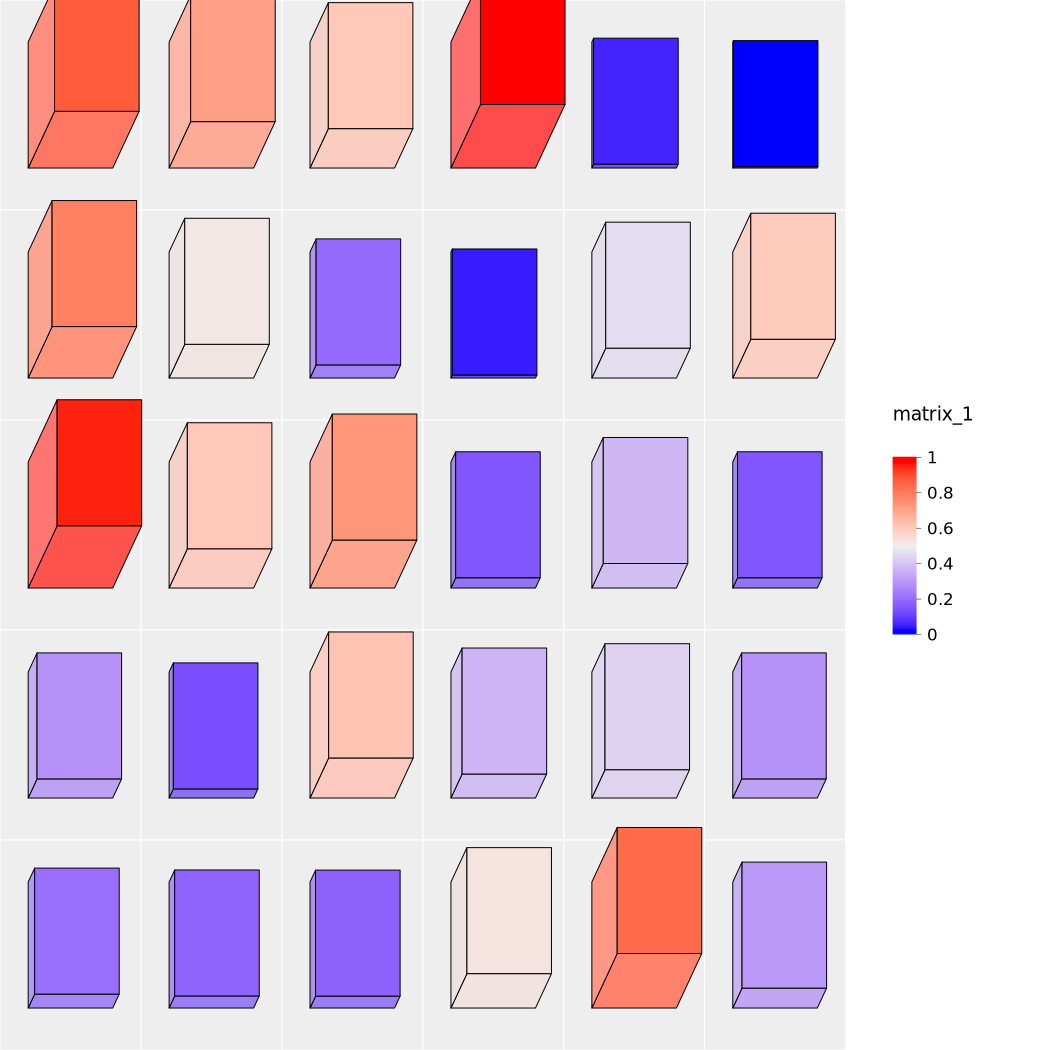

In [4]:
ht3d.draw()

## Heatmap3D with row and column names

Since `Heatmap3D` returns a `Heatmap`, use `row_labels` and
`column_labels` (the standard Heatmap parameters).

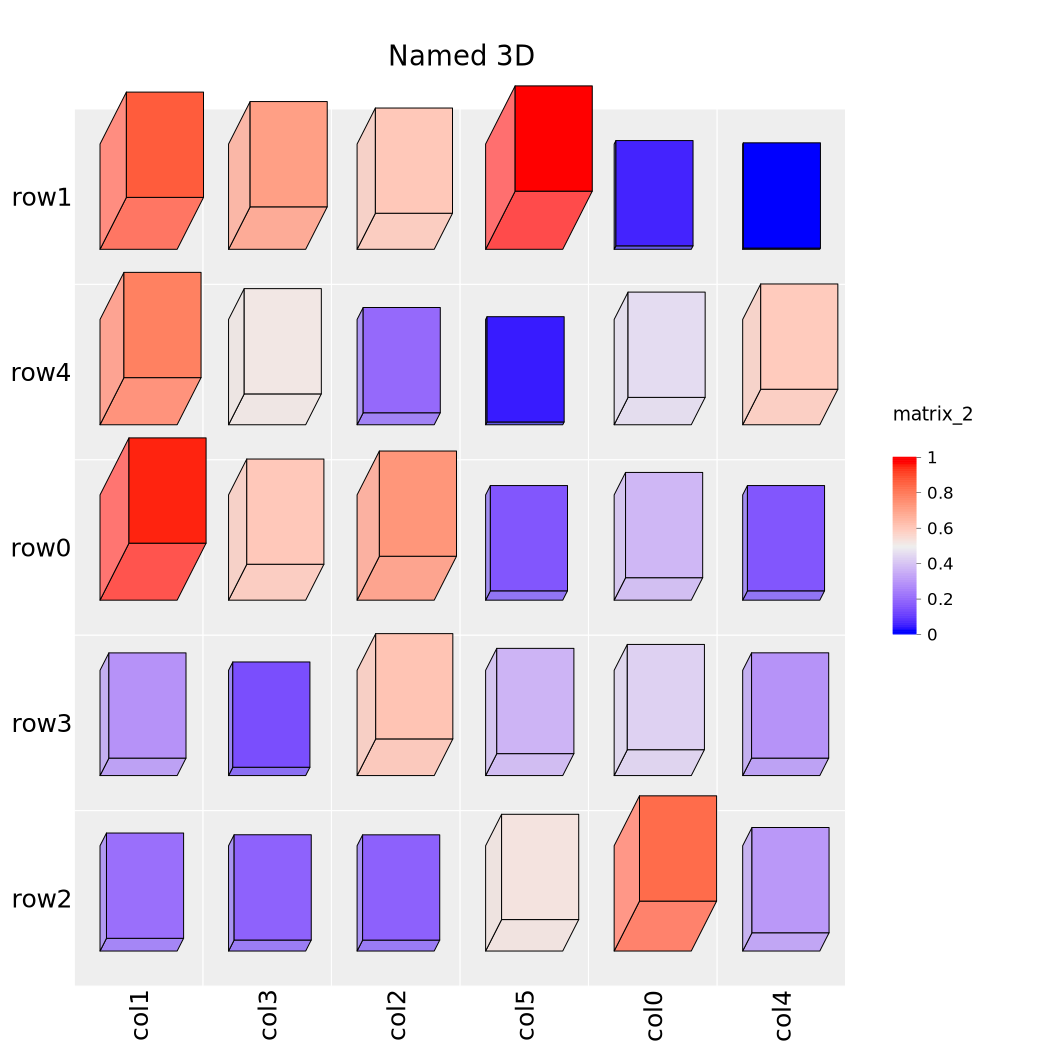

In [5]:
ht3d_named = Heatmap3D(
    mat,
    row_labels=[f"row{i}" for i in range(5)],
    column_labels=[f"col{j}" for j in range(6)],
    column_title="Named 3D",
)
ht3d_named.draw()

## Heatmap3D with custom color function

A `color_ramp2` function can be passed via the `col` argument, just like
a regular `Heatmap`.

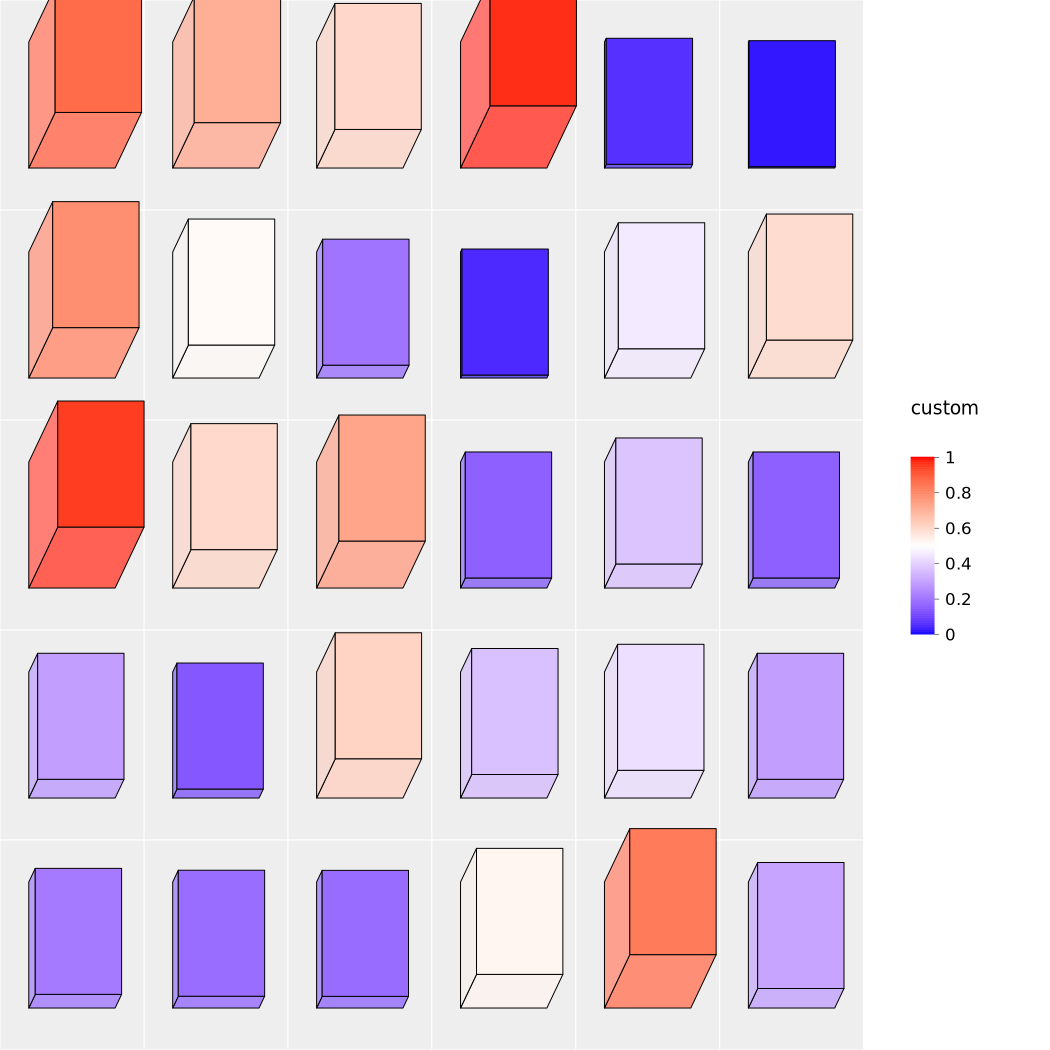

In [6]:
col_fun = color_ramp2([0, 0.5, 1], ["blue", "white", "red"])

ht3d_col = Heatmap3D(mat, col=col_fun, name="custom")
ht3d_col.draw()

## Varying the bar_angle

The `bar_angle` parameter controls the projection angle of the 3D bars.
It ranges from 0 to 90 degrees. A larger angle pushes the bars more
upward.

In [7]:
for angle in [20, 45, 60, 80]:
    ht = Heatmap3D(mat, bar_angle=float(angle))
    print(f"bar_angle={angle}: construction OK = {isinstance(ht, Heatmap)}")

bar_angle=20: construction OK = True
bar_angle=45: construction OK = True
bar_angle=60: construction OK = True
bar_angle=80: construction OK = True


## Heatmap3D with a wider range of values

Let's try a 10x10 matrix with named rows and columns, and a custom
color mapping.

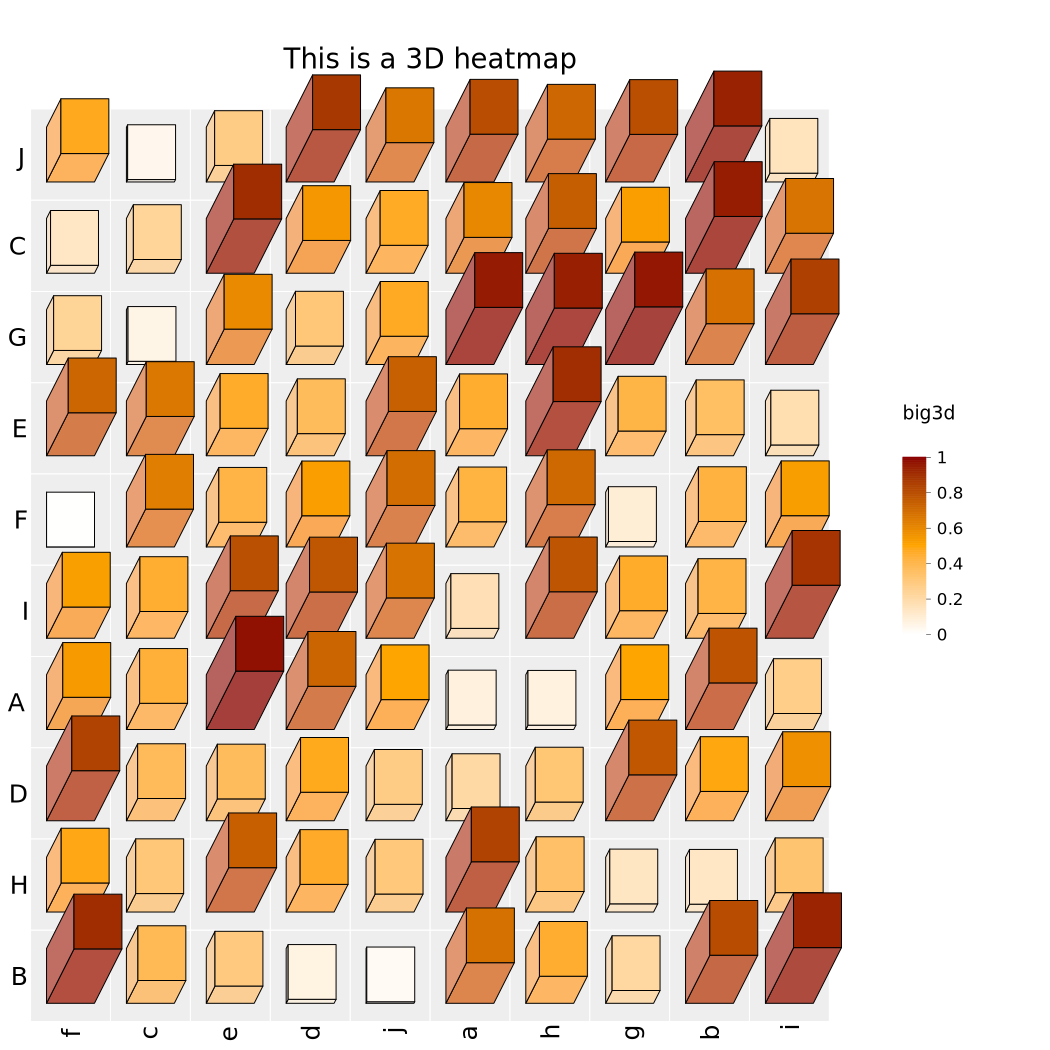

In [8]:
np.random.seed(7)
mat10 = np.random.rand(10, 10)
row_names = [chr(65 + i) for i in range(10)]  # A-J
col_names = [chr(97 + i) for i in range(10)]  # a-j

ht3d_big = Heatmap3D(
    mat10,
    row_labels=row_names,
    column_labels=col_names,
    column_title="This is a 3D heatmap",
    col=color_ramp2([0, 0.5, 1], ["white", "orange", "darkred"]),
    name="big3d",
)
ht3d_big.draw()

## The `bar3D` function

`bar3D` is the low-level grid drawing primitive that draws individual 3D
bars at given (x, y) positions. It is used internally by `Heatmap3D`'s
`layer_fun`. For standalone matrix visualization, use `Heatmap3D` directly.

Type: Heatmap


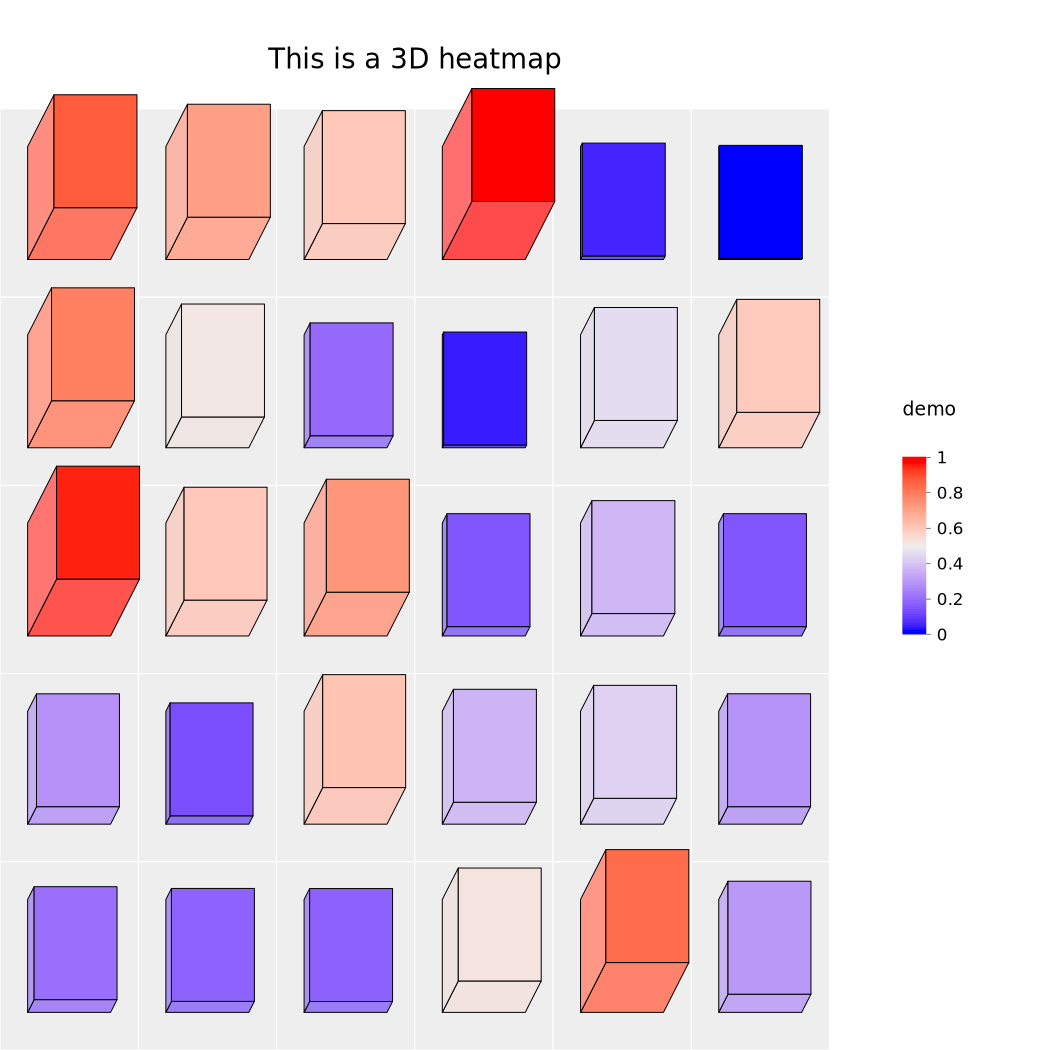

In [9]:
# bar3D is now a grid-level primitive (like R's bar3D).
# For matrix visualization, use Heatmap3D directly:
ht = Heatmap3D(mat, name="demo", column_title="This is a 3D heatmap",)
print(f"Type: {type(ht).__name__}")
ht.draw()

## Heatmap3D with different color functions

Type: Heatmap


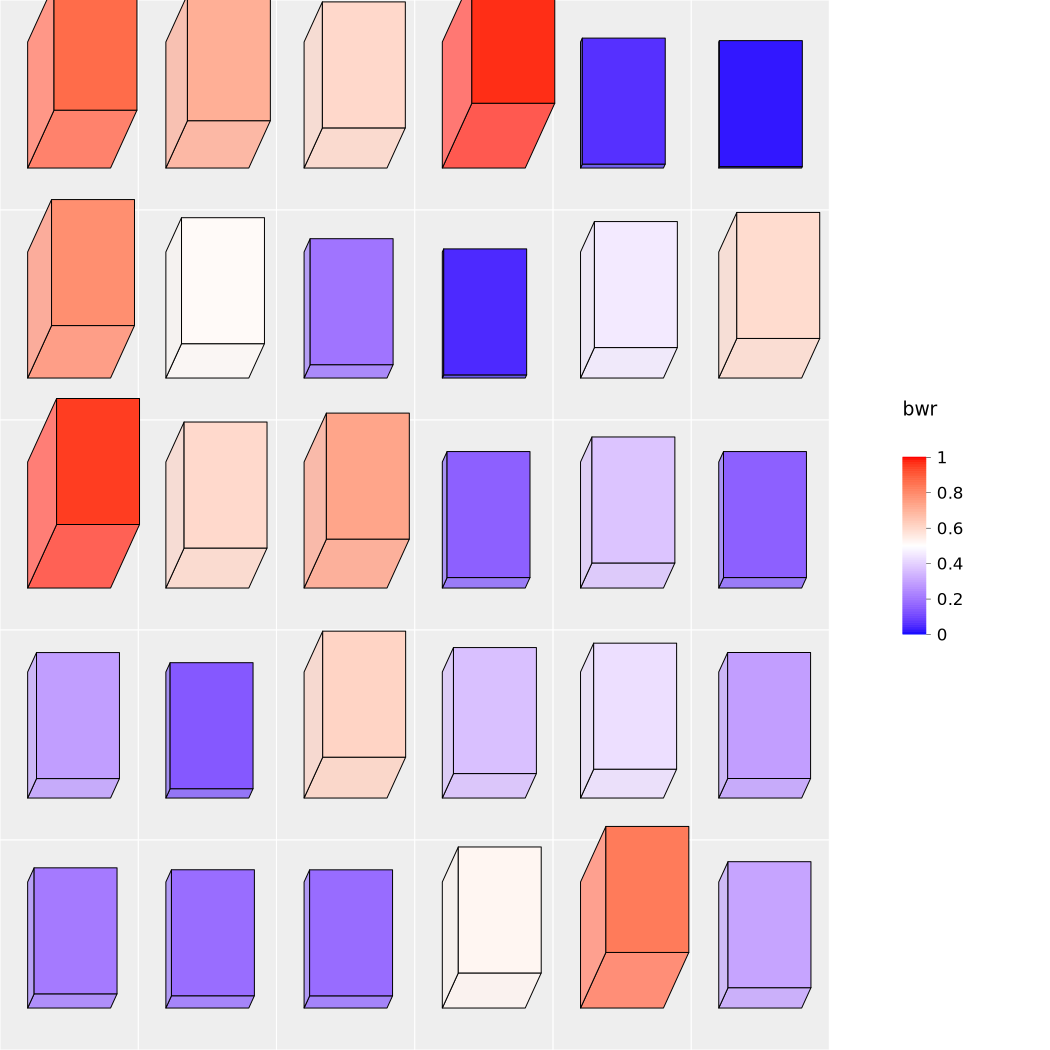

In [10]:
col_fun = color_ramp2([0, 0.5, 1], ["blue", "white", "red"])
ht_col = Heatmap3D(mat, col=col_fun, name="bwr")
print(f"Type: {type(ht_col).__name__}")
ht_col.draw()

## Heatmap3D with names and title

Type: Heatmap


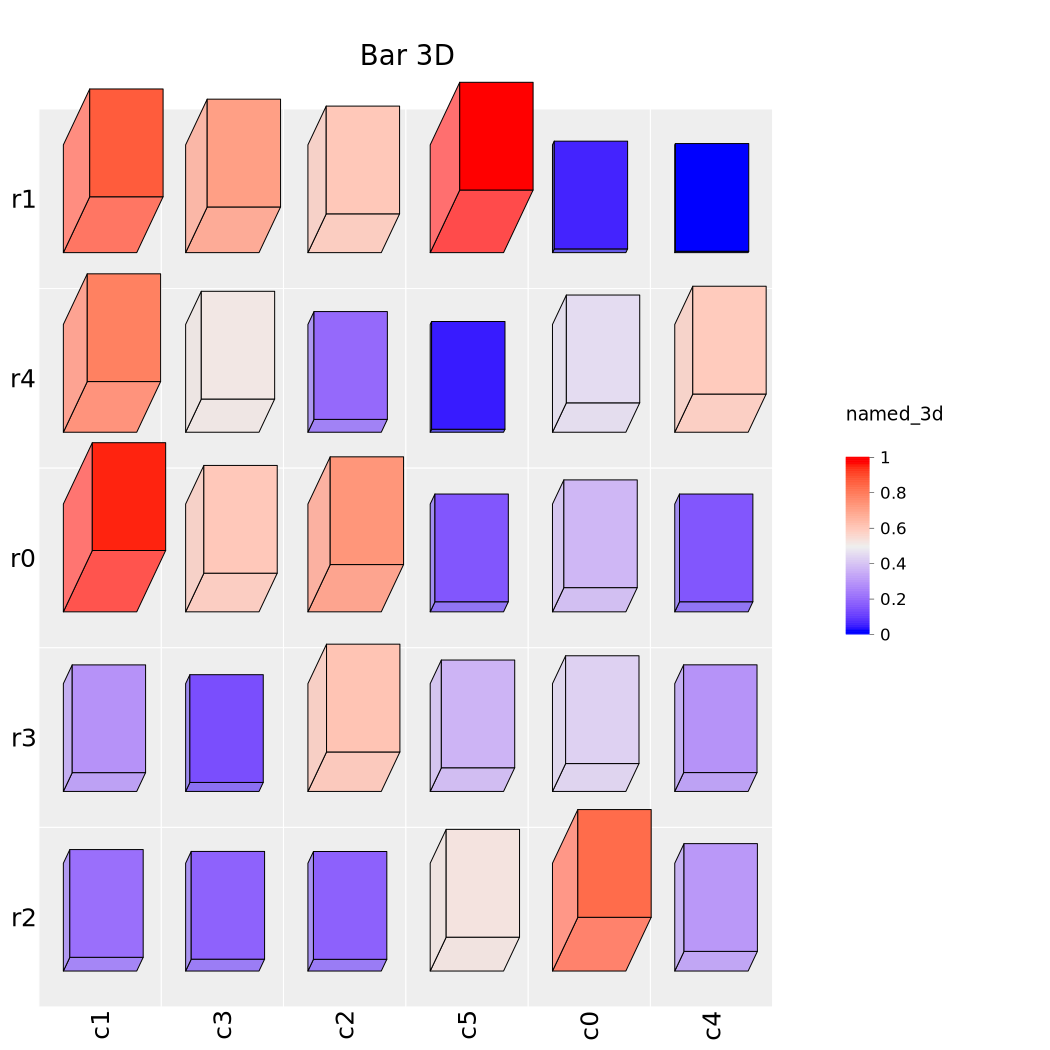

In [11]:
ht_named = Heatmap3D(
    mat,
    row_labels=[f"r{i}" for i in range(5)],
    column_labels=[f"c{j}" for j in range(6)],
    column_title="Bar 3D",
    name="named_3d",
)
print(f"Type: {type(ht_named).__name__}")
ht_named.draw()

## Heatmap3D with non-negative matrix

Ensure that taking absolute values of a matrix with negatives also works.

Type: Heatmap


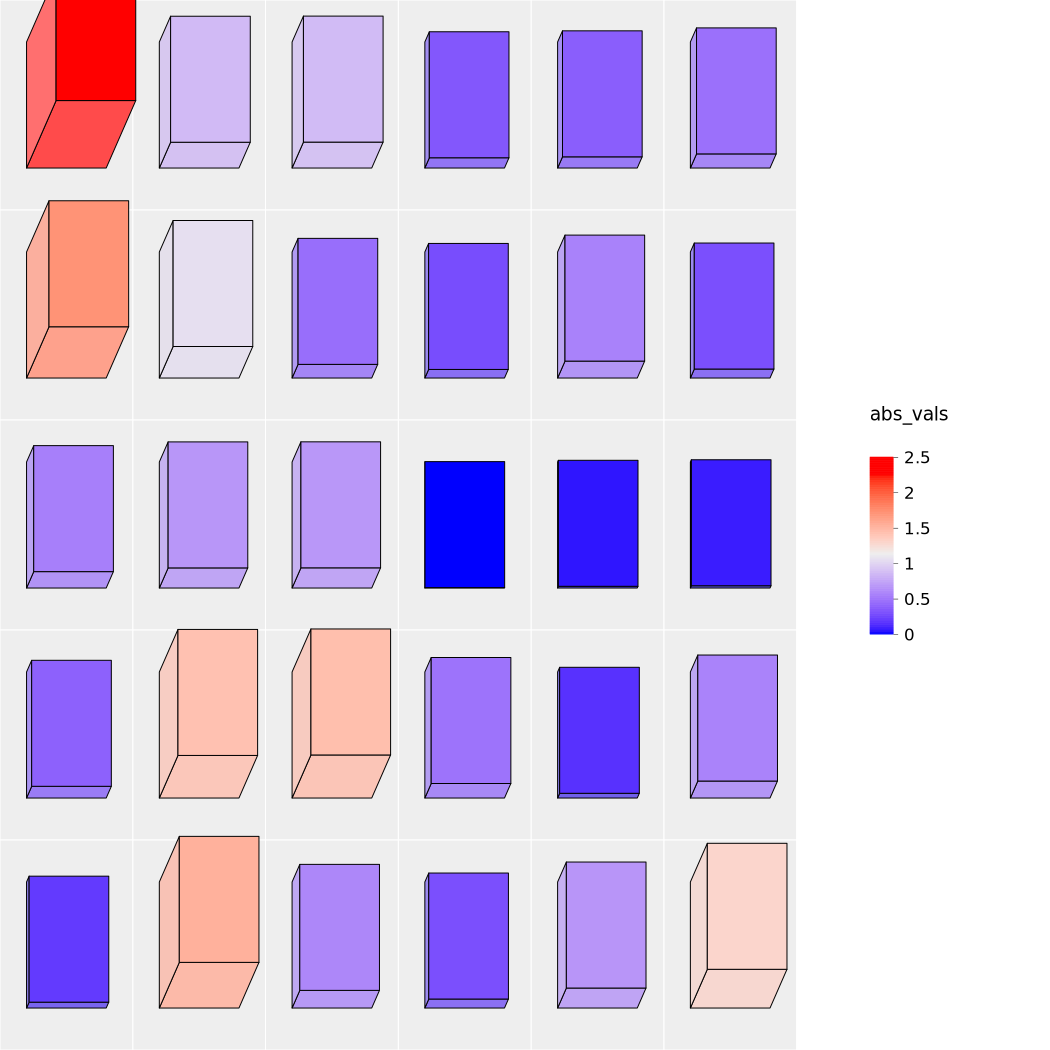

In [12]:
mat_neg = np.random.randn(5, 6)
mat_pos = np.abs(mat_neg)
ht_pos = Heatmap3D(mat_pos, name="abs_vals")
print(f"Type: {type(ht_pos).__name__}")
ht_pos.draw()

## Heatmap3D with color_ramp2 using diverging colors

Diverging color Heatmap3D: True


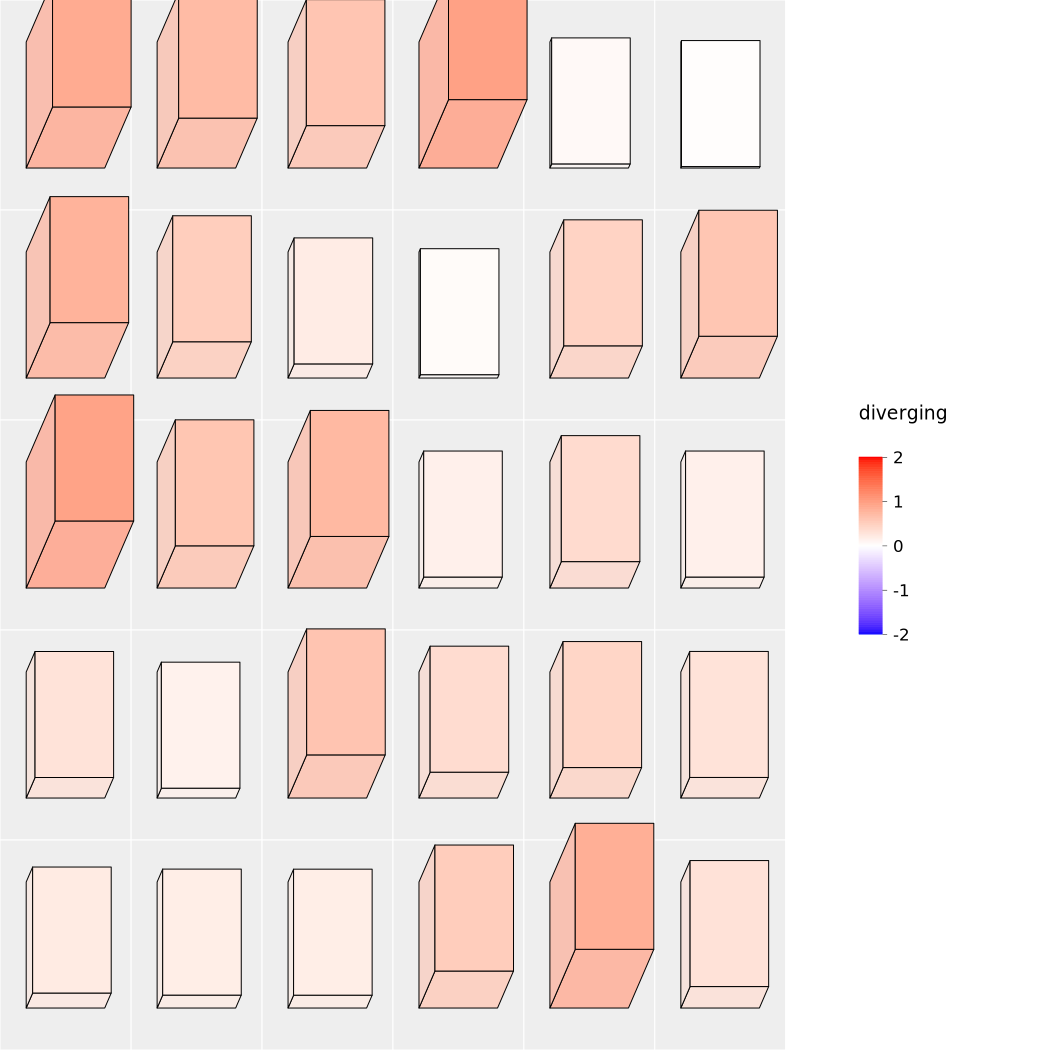

In [13]:
col_fun_div = color_ramp2([-2, 0, 2], ["blue", "white", "red"])
ht3d_div = Heatmap3D(mat, col=col_fun_div, name="diverging")
print(f"Diverging color Heatmap3D: {isinstance(ht3d_div, Heatmap)}")
ht3d_div.draw()

## Summary

This tutorial covered the 3D visualization capabilities:

- `Heatmap3D(mat)`: creates a 3D bar-style heatmap
  - Returns a `Heatmap` object — clustering, annotations, legends, composition all work
  - Accepts `row_labels`, `column_labels`, `column_title`, `col`, `bar_angle`
  - Requires non-negative input values
  - Supports all standard `Heatmap` arguments via `**kwargs`
  - Parameters: `bar_rel_width` (0.6), `bar_rel_height` (0.6), `bar_angle` (60)
- `bar3D(x, y, w, h, l, theta, fill)`: low-level grid drawing primitive
  - Used internally by `Heatmap3D`'s `layer_fun`
  - Draws 3D bars with front/left/top face shading
- The `bar_angle` parameter (0–90) controls the 3D projection angle
- Best used on small matrices for visual clarity